## Importing libraries and dataset reading

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
dem_df = pd.read_excel("PGCB_date_power_demand.xlsx")

In [6]:
wea_df = pd.read_excel("weather_data.xlsx")

In [7]:
eco_df = pd.read_csv("economic_full_1.csv") 

## Exploratory Data Analysis (EDA)

In [8]:
dem_df.shape

(92650, 15)

In [9]:
wea_df.shape

(107307, 10)

In [10]:
eco_df.shape

(1516, 69)

In [11]:
dem_df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [12]:
dem_df.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,92650,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,2020-05-17 03:52:07.609282,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-10-31 06:15:00,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,2020-05-21 15:30:00,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,2022-12-03 18:22:30,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,2025-06-17 12:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000
std,NaN,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897


In [13]:
dem_df = dem_df.sort_values('datetime')

In [14]:
dem_df = dem_df.set_index('datetime')

In [15]:
dem_df = dem_df.sort_index()

In [16]:
dem_df.index.diff().value_counts().head()

datetime
0 days 01:00:00    83649
0 days 00:30:00     8336
0 days 00:00:00      432
0 days 02:00:00      178
0 days 03:00:00       11
Name: count, dtype: int64

In [17]:
dem_df.index.duplicated().sum()

np.int64(432)

In [18]:
dem_df = dem_df[~dem_df.index.duplicated()]

In [19]:
dem_df = dem_df.asfreq('h')

In [20]:
dem_df.index.to_series().diff().value_counts()

datetime
0 days 01:00:00    89100
Name: count, dtype: int64

In [21]:
dem_df.shape

(89101, 14)

In [22]:
dem_df.isnull().sum()

generation_mw            1055
demand_mw                1055
load_shedding            1055
gas                      1055
liquid_fuel              1055
coal                     1055
hydro                    1055
solar                   21572
wind                    71192
india_bheramara_hvdc     1055
india_tripura            1055
india_adani             82062
nepal                   83968
remarks                 83349
dtype: int64

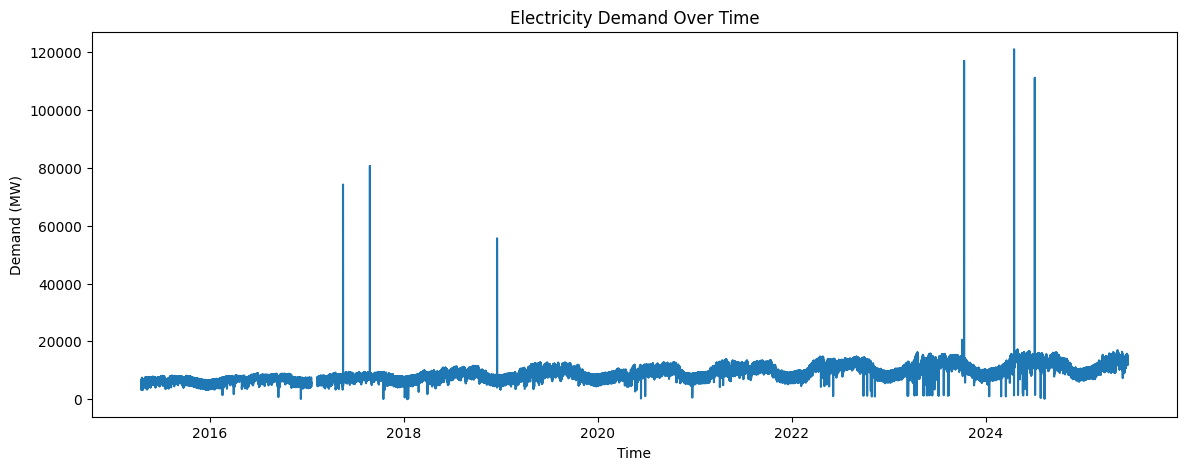

In [23]:
plt.figure(figsize=(14,5))
plt.plot(dem_df.index, dem_df['demand_mw'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

## Data cleaning

In [24]:
dem_df = dem_df.drop(columns=['india_adani', 'nepal', 'remarks'])

In [25]:
dem_df['solar'] = dem_df['solar'].fillna(0)
dem_df['wind'] = dem_df['wind'].fillna(0)

In [26]:
dem_df = dem_df.ffill()

In [27]:
dem_df.isnull().sum()

generation_mw           0
demand_mw               0
load_shedding           0
gas                     0
liquid_fuel             0
coal                    0
hydro                   0
solar                   0
wind                    0
india_bheramara_hvdc    0
india_tripura           0
dtype: int64

In [28]:
q1 = dem_df['demand_mw'].quantile(0.25)
q3 = dem_df['demand_mw'].quantile(0.75)
iqr = q3 - q1

In [29]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [30]:
dem_df['demand_mw'] = dem_df['demand_mw'].clip(lower, upper)

In [31]:
lower

np.float64(997.5)

In [32]:
upper

np.float64(16297.5)

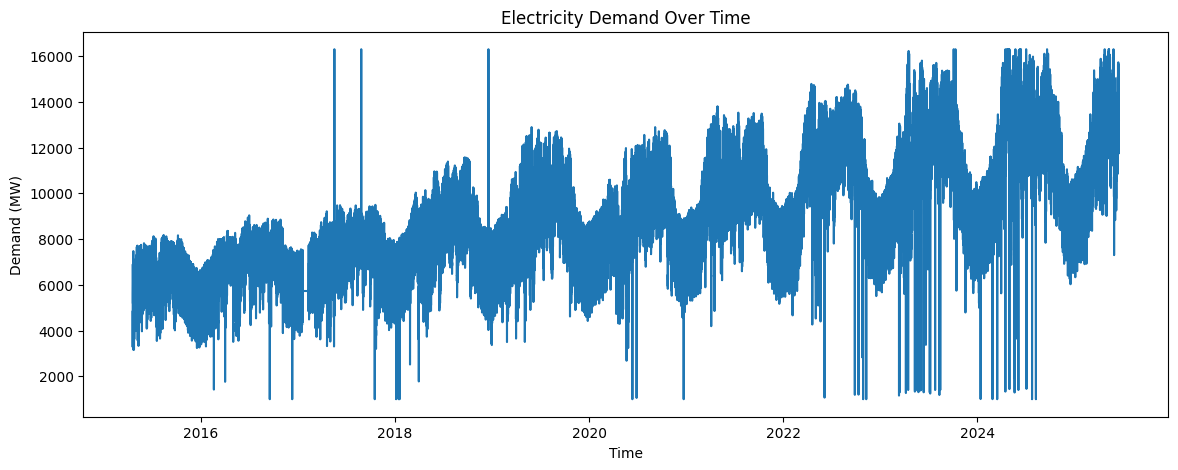

In [33]:
plt.figure(figsize=(14,5))
plt.plot(dem_df.index, dem_df['demand_mw'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

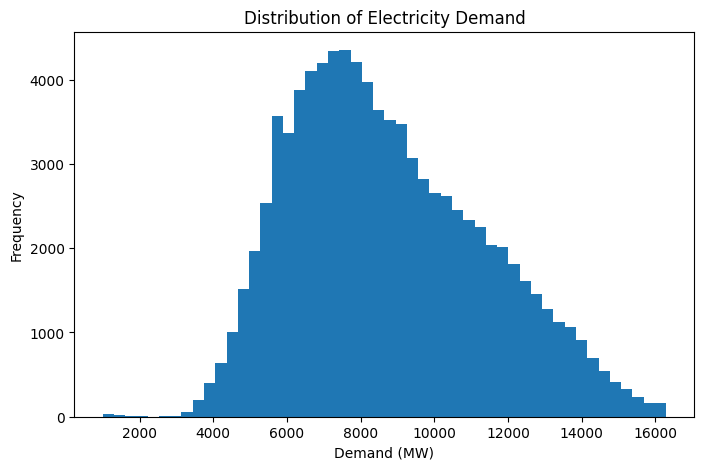

In [34]:
plt.figure(figsize=(8,5))
plt.hist(dem_df['demand_mw'], bins=50)
plt.title("Distribution of Electricity Demand")
plt.xlabel("Demand (MW)")
plt.ylabel("Frequency")
plt.show()

## Feature Engineering

In [35]:
dem_df['l1'] = dem_df['demand_mw'].shift(1)

In [36]:
dem_df['l2'] = dem_df['demand_mw'].shift(2)

In [37]:
dem_df['l3'] = dem_df['demand_mw'].shift(3)

In [38]:
dem_df['l24'] = dem_df['demand_mw'].shift(24)

In [39]:
dem_df['l168'] = dem_df['demand_mw'].shift(168)

In [40]:
dem_df.head(30)

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,l1,l2,l3,l24,l168
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4821.0,NaN,NaN,NaN,NaN
2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3612.0,4821.0,NaN,NaN,NaN
2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3727.0,3612.0,4821.0,NaN,NaN
2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3632.0,3727.0,3612.0,NaN,NaN
2015-04-19 05:00:00,3283.0,3283.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3641.0,3632.0,3727.0,NaN,NaN
2015-04-19 06:00:00,3444.0,3444.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3283.0,3641.0,3632.0,NaN,NaN
2015-04-19 07:00:00,3592.0,3592.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3444.0,3283.0,3641.0,NaN,NaN
2015-04-19 08:00:00,4049.0,4049.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3592.0,3444.0,3283.0,NaN,NaN


In [41]:
dem_df['target'] = dem_df['demand_mw'].shift(-1)

In [42]:
dem_df = dem_df.dropna()

In [43]:
dem_df.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,l1,l2,l3,l24,l168,target
datetime,,,,,,,,,,,,,,,,,
2015-04-26 00:00:00,6167.0,6167.0,0.0,4958.0,554.0,156.0,46.0,0.0,0.0,453.0,0.0,6167.0,6167.0,6167.0,5197.0,4821.0,6167.0
2015-04-26 01:00:00,6167.0,6167.0,0.0,4958.0,554.0,156.0,46.0,0.0,0.0,453.0,0.0,6167.0,6167.0,6167.0,4987.0,3612.0,6167.0
2015-04-26 02:00:00,6167.0,6167.0,0.0,4958.0,554.0,156.0,46.0,0.0,0.0,453.0,0.0,6167.0,6167.0,6167.0,4703.0,3727.0,6167.0
2015-04-26 03:00:00,6167.0,6167.0,0.0,4958.0,554.0,156.0,46.0,0.0,0.0,453.0,0.0,6167.0,6167.0,6167.0,4510.0,3632.0,6167.0
2015-04-26 04:00:00,6167.0,6167.0,0.0,4958.0,554.0,156.0,46.0,0.0,0.0,453.0,0.0,6167.0,6167.0,6167.0,4230.0,3641.0,6167.0


In [44]:
dem_df.tail()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,l1,l2,l3,l24,l168,target
datetime,,,,,,,,,,,,,,,,,
2025-06-17 07:00:00,11745.0,11745.0,0.0,5614.0,494.0,3487.0,132.0,128.0,28.0,924.0,26.0,11805.0,12062.0,12698.0,12646.0,11787.0,11896.0
2025-06-17 08:00:00,11896.0,11896.0,0.0,5678.0,490.0,3470.0,132.0,219.0,57.0,924.0,24.0,11745.0,11805.0,12062.0,12876.0,11642.0,12290.0
2025-06-17 09:00:00,12290.0,12290.0,0.0,6065.0,531.0,3491.0,132.0,203.0,16.0,924.0,24.0,11896.0,11745.0,11805.0,13155.0,11635.0,12443.0
2025-06-17 10:00:00,12443.0,12443.0,0.0,5900.0,552.0,3601.0,172.0,215.0,31.0,923.0,26.0,12290.0,11896.0,11745.0,13569.0,11539.0,12826.0
2025-06-17 11:00:00,12826.0,12826.0,0.0,5896.0,595.0,3591.0,172.0,324.0,37.0,924.0,26.0,12443.0,12290.0,11896.0,13816.0,11761.0,13139.0


## Merging weather data 
  (After data cleaning)

In [45]:
wea_df.head()

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,23.7961,90.3805,9,21600,Asia/Dhaka,GMT+6,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
3,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
4,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0


In [46]:
wea_df.dtypes

latitude                 object
longitude                object
elevation                object
utc_offset_seconds       object
timezone                 object
timezone_abbreviation    object
Unnamed: 6               object
Unnamed: 7               object
Unnamed: 8               object
Unnamed: 9               object
dtype: object

In [47]:
weatherdf = pd.read_excel("weather_data.xlsx" , header=3)

In [48]:
weatherdf.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [49]:
weatherdf.dtypes

time                              datetime64[us]
temperature_2m (°C)                      float64
relative_humidity_2m (%)                   int64
apparent_temperature (°C)                float64
precipitation (mm)                       float64
dew_point_2m (°C)                        float64
soil_temperature_0_to_7cm (°C)           float64
wind_direction_10m (°)                     int64
cloud_cover (%)                            int64
sunshine_duration (s)                    float64
dtype: object

In [50]:
weatherdf = weatherdf.rename(columns={'time': 'datetime'})

In [51]:
weatherdf = weatherdf.sort_values('datetime')

In [52]:
weatherdf

,datetime,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0
...,...,...,...,...,...,...,...,...,...,...
107299,2026-03-29 19:00:00,25.5,81,29.0,0.0,22.0,30.1,87,10,0.0
107300,2026-03-29 20:00:00,25.5,82,29.4,0.0,22.1,28.9,163,25,0.0
107301,2026-03-29 21:00:00,25.0,83,29.0,0.0,22.0,27.9,203,16,0.0
107302,2026-03-29 22:00:00,24.5,87,28.8,0.0,22.0,27.1,153,5,0.0


In [53]:
dem_df = dem_df.merge(weatherdf, on='datetime', how='left')

In [54]:
dem_df.isnull().sum()

datetime                          0
generation_mw                     0
demand_mw                         0
load_shedding                     0
gas                               0
liquid_fuel                       0
coal                              0
hydro                             0
solar                             0
wind                              0
india_bheramara_hvdc              0
india_tripura                     0
l1                                0
l2                                0
l3                                0
l24                               0
l168                              0
target                            0
temperature_2m (°C)               0
relative_humidity_2m (%)          0
apparent_temperature (°C)         0
precipitation (mm)                0
dew_point_2m (°C)                 0
soil_temperature_0_to_7cm (°C)    0
wind_direction_10m (°)            0
cloud_cover (%)                   0
sunshine_duration (s)             0
dtype: int64

## Merging economic data
   (After choosing appropriate features
   and performing data cleaning)

In [55]:
eco_df.columns

Index(['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961',
       '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979',
       '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='str')

In [56]:
eco_df.shape

(1516, 69)

In [57]:
ecolong_df = eco_df.melt(
    id_vars = ['Country Name','Indicator Name','Indicator Code'],
    var_name = 'Year',
    value_name = 'Value'
)

In [58]:
ecolong_df.shape

(100056, 5)

In [59]:
ecolong_df.head()

,Country Name,Indicator Name,Indicator Code,Year,Value
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,1960,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,1960,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,1960,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,1960,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,1960,NaN


In [60]:
ecolong_df.isnull().sum()

Country Name          0
Indicator Name        0
Indicator Code        0
Year                  0
Value             55598
dtype: int64

In [61]:
ecolong_df['Year'] = ecolong_df['Year'].astype(int)

In [62]:
ecolong_df.dtypes

Country Name          str
Indicator Name        str
Indicator Code        str
Year                int64
Value             float64
dtype: object

In [63]:
filt = ecolong_df['Indicator Name'].str.lower().str.contains('gdp')

In [64]:
ecolong_filt = ecolong_df[filt]

In [65]:
ecolong_filt.shape

(5610, 5)

In [66]:
ecolong_filt.head()

,Country Name,Indicator Name,Indicator Code,Year,Value
93,X,"Government expenditure per student, tertiary (...",SE.XPD.TERT.PC.ZS,1960,NaN
94,X,"Government expenditure per student, primary (%...",SE.XPD.PRIM.PC.ZS,1960,NaN
153,X,Net lending (+) / net borrowing (-) (% of GDP),GC.NLD.TOTL.GD.ZS,1960,NaN
154,X,"Net incurrence of liabilities, total (% of GDP)",GC.LBL.TOTL.GD.ZS,1960,NaN
155,X,Net acquisition of financial assets (% of GDP),GC.AST.TOTL.GD.ZS,1960,NaN


In [67]:
ecolong_filt = ecolong_filt[['Indicator Name', 'Year', 'Value']]

In [68]:
ecolong_filt.columns

Index(['Indicator Name', 'Year', 'Value'], dtype='str')

In [69]:
ecolong_filt.dtypes

Indicator Name        str
Year                int64
Value             float64
dtype: object

In [70]:
eco_final = ecolong_filt.pivot(
    index='Year',
    columns='Indicator Name',
    values='Value'
).reset_index()

In [71]:
eco_final.shape

(66, 86)

In [72]:
eco_final.head()

Indicator Name,Year,"Agriculture, forestry, and fishing, value added (% of GDP)",Broad money (% of GDP),Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP),Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP),"Central government debt, total (% of GDP)","Claims on central government, etc. (% GDP)",Claims on other sectors of the domestic economy (% of GDP),Coal rents (% of GDP),Current account balance (% of GDP),...,Price level ratio of PPP conversion factor (GDP) to market exchange rate,Research and development expenditure (% of GDP),"Revenue, excluding grants (% of GDP)","Services, value added (% of GDP)","Stocks traded, total value (% of GDP)",Tax revenue (% of GDP),Total natural resources rents (% of GDP),Trade (% of GDP),Trade in services (% of GDP),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)"
0,1960,57.474312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.551872,NaN,NaN,NaN,19.303944,NaN,NaN
1,1961,57.988236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.217646,NaN,NaN,NaN,22.482352,NaN,NaN
2,1962,57.018574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.017564,NaN,NaN,NaN,21.554848,NaN,NaN
3,1963,57.146668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.048739,NaN,NaN,NaN,21.639763,NaN,NaN
4,1964,53.356837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,36.220139,NaN,NaN,NaN,24.150268,NaN,NaN


In [73]:
eco_final.columns

Index(['Year', 'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Broad money (% of GDP)',
       'Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP)',
       'Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)',
       'Central government debt, total (% of GDP)',
       'Claims on central government, etc. (% GDP)',
       'Claims on other sectors of the domestic economy (% of GDP)',
       'Coal rents (% of GDP)', 'Current account balance (% of GDP)',
       'Current health expenditure (% of GDP)',
       'Discrepancy in expenditure estimate of GDP (constant LCU)',
       'Discrepancy in expenditure estimate of GDP (current LCU)',
       'Domestic credit provided by financial sector (% of GDP)',
       'Domestic credit to private sector (% of GDP)',
       'Domestic credit to private sector by banks (% of GDP)',
       'Domestic general government health expenditure (% of GDP)',
       'Energy intensity level of primary energy (MJ/$2021 PPP GDP)',
 

In [74]:
eco_final.columns.name = None

In [75]:
eco_final.head()

,Year,"Agriculture, forestry, and fishing, value added (% of GDP)",Broad money (% of GDP),Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP),Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP),"Central government debt, total (% of GDP)","Claims on central government, etc. (% GDP)",Claims on other sectors of the domestic economy (% of GDP),Coal rents (% of GDP),Current account balance (% of GDP),...,Price level ratio of PPP conversion factor (GDP) to market exchange rate,Research and development expenditure (% of GDP),"Revenue, excluding grants (% of GDP)","Services, value added (% of GDP)","Stocks traded, total value (% of GDP)",Tax revenue (% of GDP),Total natural resources rents (% of GDP),Trade (% of GDP),Trade in services (% of GDP),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)"
0,1960,57.474312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.551872,NaN,NaN,NaN,19.303944,NaN,NaN
1,1961,57.988236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.217646,NaN,NaN,NaN,22.482352,NaN,NaN
2,1962,57.018574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.017564,NaN,NaN,NaN,21.554848,NaN,NaN
3,1963,57.146668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.048739,NaN,NaN,NaN,21.639763,NaN,NaN
4,1964,53.356837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,36.220139,NaN,NaN,NaN,24.150268,NaN,NaN


In [76]:
dem_df['Year'] = dem_df['datetime'].dt.year

In [77]:
dem_df[['datetime', 'Year']].head()

,datetime,Year
0,2015-04-26 00:00:00,2015
1,2015-04-26 01:00:00,2015
2,2015-04-26 02:00:00,2015
3,2015-04-26 03:00:00,2015
4,2015-04-26 04:00:00,2015


In [78]:
dem_df = dem_df.merge(eco_final, on='Year', how='left')

In [79]:
dem_df.isnull().sum()

datetime                                                                                                0
generation_mw                                                                                           0
demand_mw                                                                                               0
load_shedding                                                                                           0
gas                                                                                                     0
                                                                                                    ...  
Tax revenue (% of GDP)                                                                              30324
Total natural resources rents (% of GDP)                                                            30324
Trade (% of GDP)                                                                                     4020
Trade in services (% of GDP)                  

In [80]:
threshold = 0.5

In [81]:
dem_df = dem_df.loc[:, dem_df.isnull().mean() < threshold]

In [82]:
dem_df = dem_df.ffill()

## Exploratory Data Analysis(EDA)

In [83]:
dem_df.isnull().sum()

datetime                                                                                            0
generation_mw                                                                                       0
demand_mw                                                                                           0
load_shedding                                                                                       0
gas                                                                                                 0
                                                                                                   ..
Tax revenue (% of GDP)                                                                              0
Total natural resources rents (% of GDP)                                                            0
Trade (% of GDP)                                                                                    0
Trade in services (% of GDP)                                                      

In [84]:
corr = dem_df.corr(numeric_only=True)
corr['target'].sort_values(ascending=False).head(10)

target                                      1.000000
demand_mw                                   0.976518
l1                                          0.949841
l24                                         0.926752
l2                                          0.920750
l3                                          0.892256
l168                                        0.865059
GDP, PPP (constant 2021 international $)    0.697672
GDP (constant LCU)                          0.697672
GDP (constant 2015 US$)                     0.697672
Name: target, dtype: float64

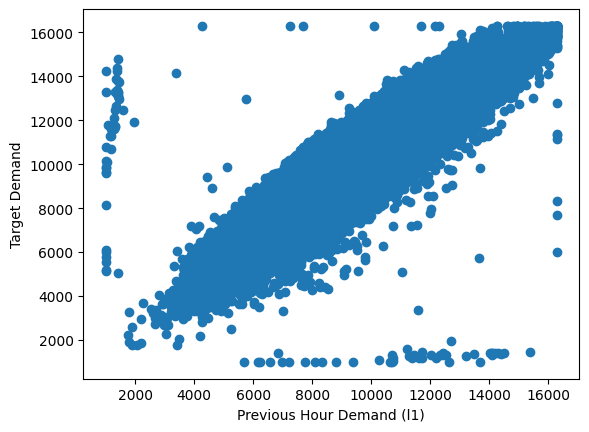

In [85]:
plt.scatter(dem_df['l1'], dem_df['target'])
plt.xlabel("Previous Hour Demand (l1)")
plt.ylabel("Target Demand")
plt.show()

In [86]:
dem_df['generation_mw'].describe()

count    8.893200e+04
mean     9.399250e+03
std      2.163611e+05
min      7.300000e+01
25%      6.746875e+03
50%      8.350050e+03
75%      1.049500e+04
max      6.452650e+07
Name: generation_mw, dtype: float64

In [87]:
dem_df=dem_df.loc[dem_df['generation_mw']<20000]

In [88]:
dem_df['generation_mw'].describe()

count    88931.000000
mean      8673.776012
std       2480.059370
min         73.000000
25%       6746.850000
50%       8350.000000
75%      10495.000000
max      16603.000000
Name: generation_mw, dtype: float64

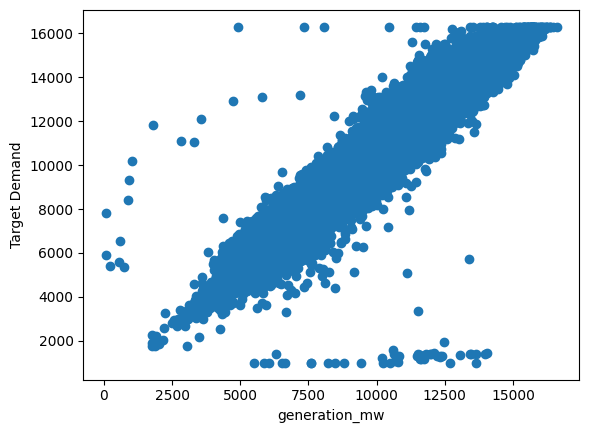

In [89]:
plt.scatter(dem_df['generation_mw'], dem_df['target'])
plt.xlabel("generation_mw")
plt.ylabel("Target Demand")
plt.show()

## Model Training

In [90]:
X = dem_df.drop(columns=['target', 'datetime','demand_mw'])
y = dem_df['target']

In [91]:
train = dem_df[dem_df['datetime'] < '2024-01-01']
test  = dem_df[dem_df['datetime'] >= '2024-01-01']

In [92]:
X_train = train.drop(columns=['target', 'datetime','demand_mw',])
y_train = train['target']

X_test = test.drop(columns=['target', 'datetime','demand_mw',])
y_test = test['target']

In [93]:
from sklearn.ensemble import RandomForestRegressor

In [94]:
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

## Evaluation of MAPE

In [95]:
pred = model.predict(X_test)

In [96]:
from sklearn.metrics import mean_absolute_percentage_error

In [97]:
mape = mean_absolute_percentage_error(y_test, pred)

In [98]:
mape

0.04074669215077506

## Evaluation of MAPE with rolling feature

In [99]:
dem_df['rolling_3'] = dem_df['demand_mw'].shift(1).rolling(3).mean()
dem_df['rolling_24'] = dem_df['demand_mw'].shift(1).rolling(24).mean()

In [100]:
dem_df = dem_df.dropna()

In [101]:
X = dem_df.drop(columns=['target', 'datetime','demand_mw'])
y = dem_df['target']

In [102]:
train = dem_df[dem_df['datetime'] < '2024-01-01']
test  = dem_df[dem_df['datetime'] >= '2024-01-01']

In [103]:
X_train = train.drop(columns=['target', 'datetime','demand_mw'])
y_train = train['target']

X_test = test.drop(columns=['target', 'datetime','demand_mw'])
y_test = test['target']

In [104]:
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [105]:
pred = model.predict(X_test)

In [106]:
mape = mean_absolute_percentage_error(y_test, pred)

In [107]:
mape

0.039711069280898174

## Feature Importance

In [108]:
feat_importance = pd.Series(model.feature_importances_, index=X_train.columns)

In [109]:
feat_importance.head(10)

generation_mw           0.928045
load_shedding           0.007292
gas                     0.001530
liquid_fuel             0.001073
coal                    0.000868
hydro                   0.000839
solar                   0.004957
wind                    0.000168
india_bheramara_hvdc    0.001565
india_tripura           0.000857
dtype: float64

In [110]:
feat_importance = feat_importance.sort_values(ascending=False)

In [111]:
feat_importance.head(10)

generation_mw                     0.928045
l1                                0.021857
load_shedding                     0.007292
sunshine_duration (s)             0.005357
solar                             0.004957
l3                                0.004186
rolling_24                        0.003180
l2                                0.002466
soil_temperature_0_to_7cm (°C)    0.002226
l24                               0.001891
dtype: float64